In [1]:
import os
import json
from PIL import Image
import matplotlib.pyplot as plt
import torch
from torch import nn, optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
import torchvision.transforms.functional as T
# Check if torchinfo is installed, otherwise install it
try:
    from torchinfo import summary
except ImportError:
    !pip install -q torchinfo
    from torchinfo import summary
from scipy.io import loadmat
from scipy.spatial.transform import Rotation as R
from torch.amp import autocast
from torch.cuda.amp import GradScaler
import numpy as np
import tqdm
from torchvision import transforms, models, ops

In [ ]:
# ============================================================
# Utility Functions 
# ============================================================

def _get_quat_bins(qPose, qClass, numNeighbors):
    ''' Find nearest quaternion classes and weights. '''
    q      = R.from_quat(qPose[[1,2,3,0]])
    qClass_r = R.from_quat(qClass[:,[1,2,3,0]])
    qDiff = q.inv() * qClass_r
    qDiff = qDiff.as_quat()
    angleVec = 2 * np.arccos(np.abs(qDiff[:,-1]))
    sortIdx  = np.argsort(angleVec)
    nClasses = sortIdx[:numNeighbors]
    nAngles  = angleVec[nClasses]
    nWeights = 1.0 - nAngles / np.pi**2
    nWeights = nWeights / np.sum(nWeights)
    return nClasses, nWeights

def quat2dcm(q):
    ''' Direction cosine matrix from quaternion (scalar-first). '''
    q = q / np.linalg.norm(q)
    q0, q1, q2, q3 = q
    dcm = np.zeros((3, 3))
    dcm[0, 0] = 2 * q0**2 - 1 + 2 * q1**2
    dcm[1, 1] = 2 * q0**2 - 1 + 2 * q2**2
    dcm[2, 2] = 2 * q0**2 - 1 + 2 * q3**2
    dcm[0, 1] = 2 * q1 * q2 + 2 * q0 * q3
    dcm[0, 2] = 2 * q1 * q3 - 2 * q0 * q2
    dcm[1, 0] = 2 * q1 * q2 - 2 * q0 * q3
    dcm[1, 2] = 2 * q2 * q3 + 2 * q0 * q1
    dcm[2, 0] = 2 * q1 * q3 + 2 * q0 * q2
    dcm[2, 1] = 2 * q2 * q3 - 2 * q0 * q1
    return dcm

def project_keypoints(q_vbs2tango, r_Vo2To_vbs, cameraMatrix, distCoeffs, keypoints):
    ''' Project 3D keypoints to 2D image coordinates. '''
    if keypoints.shape[0] != 3:
        keypoints = np.transpose(keypoints)
    keypoints = np.vstack((keypoints, np.ones((1, keypoints.shape[1]))))
    pose_mat = np.hstack((np.transpose(quat2dcm(q_vbs2tango)),
                          np.expand_dims(r_Vo2To_vbs, 1)))
    xyz = np.dot(pose_mat, keypoints)
    x0, y0 = xyz[0,:] / xyz[2,:], xyz[1,:] / xyz[2,:]
    r2 = x0*x0 + y0*y0
    cdist = 1 + distCoeffs[0]*r2 + distCoeffs[1]*r2*r2 + distCoeffs[4]*r2*r2*r2
    x = x0*cdist + distCoeffs[2]*2*x0*y0 + distCoeffs[3]*(r2 + 2*x0*x0)
    y = y0*cdist + distCoeffs[2]*(r2 + 2*y0*y0) + distCoeffs[3]*2*x0*y0
    points2D = np.vstack((cameraMatrix[0,0]*x + cameraMatrix[0,2],
                          cameraMatrix[1,1]*y + cameraMatrix[1,2]))
    return points2D

def load_tango_3d_keypoints(mat_dir):
    vertices = loadmat(mat_dir)['tango3Dpoints']
    return np.transpose(np.array(vertices, dtype=np.float32))

def load_camera_intrinsics(camera_json):
    with open(camera_json) as f:
        cam = json.load(f)
    cameraMatrix = np.array(cam['cameraMatrix'], dtype=np.float32)
    distCoeffs   = np.array(cam['distCoeffs'],   dtype=np.float32)
    return cameraMatrix, distCoeffs

In [3]:
def get_discrete_classes(m):
    """
    Optimized version using a single random call and vectorized operations.
    """
    x = np.random.rand(m, 3)
    theta1 = 2 * np.pi * x[:, 1]
    theta2 = 2 * np.pi * x[:, 2]

    r1 = np.sqrt(1 - x[:, 0])
    r2 = np.sqrt(x[:, 0])

    # Vectorized stack
    quats = np.zeros((m, 4))
    quats[:, 0] = np.sin(theta1) * r1
    quats[:, 1] = np.cos(theta1) * r1
    quats[:, 2] = np.sin(theta2) * r2
    quats[:, 3] = np.cos(theta2) * r2

    return quats

class Speed(Dataset):
    def __init__(self, images_dir, json_dir, transform=None):
        self.images_dir = images_dir
        self.json_dir = json_dir
        self.transform = transform
        self.num_classes = 5000
        self.num_neighbors = 25

        # Load shared resources once
        self.attClassesMAT = loadmat('/kaggle/input/datasets/raghavmadan07/atlitude/attitudeClasses.mat')['qClass']
        self.keypts3d = load_tango_3d_keypoints('/kaggle/input/datasets/raghavmadan07/tangopoint/tangoPoints.mat')
        self.cameraMatrix, self.distCoeffs = load_camera_intrinsics('/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/camera.json')

        with open(self.json_dir, 'r') as f:
            annotations = json.load(f)
            # Filter files that actually exist to avoid runtime errors
            self.filenames = [a['filename'] for a in annotations if os.path.exists(os.path.join(self.images_dir, a['filename']))]
            self.lookup = {a['filename']: a for a in annotations}

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        filename = self.filenames[idx]
        ann = self.lookup[filename]

        image = Image.open(os.path.join(self.images_dir, filename)).convert('RGB')

        q_vbs2tango = np.array(ann["q_vbs2tango_true"], dtype=np.float32)
        r_Vo2To_vbs = np.array(ann['r_Vo2To_vbs_true'], dtype=np.float32)

        # Lazy processing: moved from __init__ to __getitem__ to speed up startup
        attClasses, attWeights = _get_quat_bins(q_vbs2tango, self.attClassesMAT, self.num_neighbors)

        yClasses = torch.zeros(self.num_classes)
        yClasses[attClasses] = 1. / self.num_neighbors

        yWeights = torch.zeros(self.num_classes)
        yWeights[attClasses] = torch.from_numpy(attWeights.astype(np.float32))

        keypts2d = project_keypoints(q_vbs2tango, r_Vo2To_vbs, self.cameraMatrix, self.distCoeffs, self.keypts3d)

        if self.transform:
            image = self.transform(image)

        return {
            'image': image,
            'filename': filename,
            'y_class': yClasses,
            'y_weight': yWeights,
            'keypoints': torch.from_numpy(keypts2d.astype(np.float32))
        }

In [4]:
import os
import json
import numpy as np
from scipy.io import loadmat
from PIL import Image
from tqdm import tqdm

import os
import json
import numpy as np
from scipy.io import loadmat
from PIL import Image
from tqdm import tqdm

def convert_to_yolo(images_dir, annotations_json_path, camera_json_path, keypoints_mat_path, output_labels_dir):
    os.makedirs(output_labels_dir, exist_ok=True)

    # === Load camera and 3D keypoints ===
    cameraMatrix, distCoeffs = load_camera_intrinsics(camera_json_path)
    keypts3d = load_tango_3d_keypoints(keypoints_mat_path)

    # === Load annotations ===
    with open(annotations_json_path, 'r') as f:
        annotations = json.load(f)
    lookup = {item['filename']: item for item in annotations}

    total_labels = 0

    # === Iterate through image files ===
    for filename in tqdm(sorted(os.listdir(images_dir))):
        if filename not in lookup:
            continue

        image_path = os.path.join(images_dir, filename)
        img = Image.open(image_path)
        img_width, img_height = img.size

        ann = lookup[filename]
        q = np.array(ann["q_vbs2tango_true"], dtype=np.float32)
        t = np.array(ann["r_Vo2To_vbs_true"], dtype=np.float32)

        try:
            keypts2d = project_keypoints(q, t, cameraMatrix, distCoeffs, keypts3d)

            xmin = np.min(keypts2d[0])
            xmax = np.max(keypts2d[0])
            ymin = np.min(keypts2d[1])
            ymax = np.max(keypts2d[1])

            width = xmax - xmin
            height = ymax - ymin
            if width <= 1 or height <= 1:
                continue  # skip very small boxes

            margin_x = width * 0.05
            margin_y = height * 0.05

            xmin = max(0, xmin - margin_x)
            xmax = min(img_width, xmax + margin_x)
            ymin = max(0, ymin - margin_y)
            ymax = min(img_height, ymax + margin_y)

            x_center = ((xmin + xmax) / 2) / img_width
            y_center = ((ymin + ymax) / 2) / img_height
            w = (xmax - xmin) / img_width
            h = (ymax - ymin) / img_height

            # === Save YOLO label ===
            yolo_txt_path = os.path.join(output_labels_dir, filename.replace('.jpg', '.txt').replace('.png', '.txt'))
            with open(yolo_txt_path, 'w') as f:
                f.write(f"0 {x_center:.6f} {y_center:.6f} {w:.6f} {h:.6f}\n")
            total_labels += 1

        except Exception as e:
            continue  # skip failed projections

    print(f"[{annotations_json_path}]")
    print("Total images:", len(os.listdir(images_dir)))
    print("Total YOLO labels generated:", total_labels)


In [5]:
convert_to_yolo(
    images_dir="/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/synthetic/images",
    annotations_json_path="/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/synthetic/train.json",
    camera_json_path="/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/camera.json",
    keypoints_mat_path="/kaggle/input/datasets/raghavmadan07/tangopoint/tangoPoints.mat",
    output_labels_dir="/kaggle/working/output_train/labels/train"
)


100%|██████████| 59960/59960 [07:57<00:00, 125.53it/s]

[/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/synthetic/train.json]
Total images: 59960
Total YOLO labels generated: 47966


In [6]:
convert_to_yolo(
    images_dir="/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/synthetic/images",
    annotations_json_path="/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/synthetic/validation.json",
    camera_json_path="/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/camera.json",
    keypoints_mat_path="/kaggle/input/datasets/raghavmadan07/tangopoint/tangoPoints.mat",
    output_labels_dir="/kaggle/working/output_val/labels/train"
)



100%|██████████| 59960/59960 [01:42<00:00, 586.26it/s]


[/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/synthetic/validation.json]
Total images: 59960
Total YOLO labels generated: 11994


In [7]:
import os

# Replace this with your actual YOLO label output directory
output_dir = '/kaggle/working/output_train/labels/train'  # or '/validation', etc.

# List all files in the output directory
all_files = os.listdir(output_dir)

# Count how many .txt files
txt_files = [f for f in all_files if f.endswith('.txt')]
txt_count = len(txt_files)

print(f" Output Directory Check: {output_dir}")
print(f"Total files found: {len(all_files)}")
print(f"Total YOLO .txt label files: {txt_count}")

# Optional: check a few sample label files
print("\nSample label files:")
print(txt_files[:5])  # Print first 5 .txt filenames


 Output Directory Check: /kaggle/working/output_train/labels/train
Total files found: 47966
Total YOLO .txt label files: 47966

Sample label files:
['img018329.txt', 'img025094.txt', 'img045330.txt', 'img022106.txt', 'img007995.txt']


In [8]:
# Replace with the full path if known, or search for it
import os

target_filename = "img006140.txt"
found = False

for root, dirs, files in os.walk("/kaggle/working"):
    if target_filename in files:
        label_path = os.path.join(root, target_filename)
        print(f" Found: {label_path}")
        with open(label_path, "r") as f:
            lines = f.readlines()
        print("📄 Contents of", target_filename)
        for line in lines:
            print(line.strip())
        found = True
        break

if not found:
    print(f" File {target_filename} not found in /kaggle/working.")


 Found: /kaggle/working/output_train/labels/train/img006140.txt
📄 Contents of img006140.txt
0 0.398558 0.456070 0.515376 0.877373


In [9]:
import os
import shutil
from glob import glob

# Source paths
img_dir = "/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/synthetic/images"
train_lbl_dir = "/kaggle/working/output_train/labels/train"
val_lbl_dir   = "/kaggle/working/output_val/labels/train"

# Destination paths
base = "/kaggle/working/yolo_dataset"
os.makedirs(f"{base}/images/train", exist_ok=True)
os.makedirs(f"{base}/images/val", exist_ok=True)
os.makedirs(f"{base}/labels/train", exist_ok=True)
os.makedirs(f"{base}/labels/val", exist_ok=True)

def copy_pairs(lbl_dir, img_dst, lbl_dst):
    copied = 0
    for lbl_path in glob(os.path.join(lbl_dir, "*.txt")):
        fname = os.path.basename(lbl_path).replace(".txt", ".jpg")
        img_path = os.path.join(img_dir, fname)
        if os.path.exists(img_path):
            shutil.copy(img_path, os.path.join(img_dst, fname))
            shutil.copy(lbl_path, os.path.join(lbl_dst, os.path.basename(lbl_path)))
            copied += 1
    return copied

# Copy files
n_train = copy_pairs(train_lbl_dir, f"{base}/images/train", f"{base}/labels/train")
n_val   = copy_pairs(val_lbl_dir, f"{base}/images/val",   f"{base}/labels/val")

print(f" TRAIN: {n_train} image-label pairs copied.")
print(f" VAL:   {n_val} image-label pairs copied.")


 TRAIN: 47966 image-label pairs copied.
 VAL:   11994 image-label pairs copied.


In [10]:
yaml_path = "/kaggle/working/custom.yaml"

with open(yaml_path, "w") as f:
    f.write(f"""\
train: {base}/images/train
val: {base}/images/val

nc: 1
names: ['object']
""")

print(" custom.yaml created.")


 custom.yaml created.


In [11]:
!pip install -q ultralytics


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.3/41.3 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 85.9 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23

In [12]:
# ============================================================
# YOLO26s Training — Maximum Accuracy Config
# ============================================================
# YOLO26 is the latest from Ultralytics (January 2026)
# - NMS-free end-to-end inference
# - Progressive Loss + STAL for better small object detection
# - MuSGD optimizer for stable training
# ============================================================

from ultralytics import YOLO

# Load YOLO26 Small — best accuracy/speed balance
model = YOLO("yolo26s.pt")

# Train with accuracy-focused config
results = model.train(
    data="/kaggle/working/custom.yaml",
    epochs=25,           # <--- OPTIMIZATION: Reduced from 150 to 75
    imgsz=800,           # <--- REVERTED: Back to 800px for maximum accuracy!
    batch=16,            # Fits on T4x2 at 800px with AMP
    amp=True,            # Mixed precision → ~2x faster, no accuracy loss
    cos_lr=True,         # Cosine LR schedule → smoother convergence
    optimizer='AdamW',   # Better than SGD for fine-tuning
    lr0=0.001,
    augment=True,        # Built-in augmentation
    patience=50,         # Early stop if no improvement for 50 epochs
    cache=True,          # Cache images in RAM → faster epochs
    device=[0, 1],       # <--- DATA PARALLELISM: Use both T4 GPUs!
    project="/kaggle/working/runs",
    name="yolo26s_satellite",
)

# NOTE: If your Kaggle session dies, resume with:
# model = YOLO("/kaggle/working/runs/yolo26s_satellite/weights/last.pt")
# model.train(resume=True)

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=True, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/custom.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=25, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:99: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /root/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at /pytorch/aten/src/ATen/native/cuda/jit_utils.cpp:1487.)
  inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 375/375 5.5it/s 1:09
                   all      11994      11994      0.978      0.969      0.993      0.916

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/25      4.28G     0.7209      0.374     0.0101         20        800: 100% ━━━━━━━━━━━━ 2998/2998 2.8it/s 17:60
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 375/375 5.9it/s 1:04
                   all      11994      11994      0.982      0.983      0.994      0.948

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/25      4.28G     0.6616     0.3363   0.009262         20        800: 100% ━━━━━━━━━━━━ 2998/2998 2.8it/s 17:59
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 375/375 5.9it/s 1:03
                   all      11994  


image 1/1 /kaggle/input/datasets/isidorotamassia/speed/speedplusv2/lightbox/images/img006206.jpg: 512x800 1 object, 122.0ms
Speed: 7.2ms preprocess, 122.0ms inference, 49.7ms postprocess per image at shape (1, 3, 512, 800)


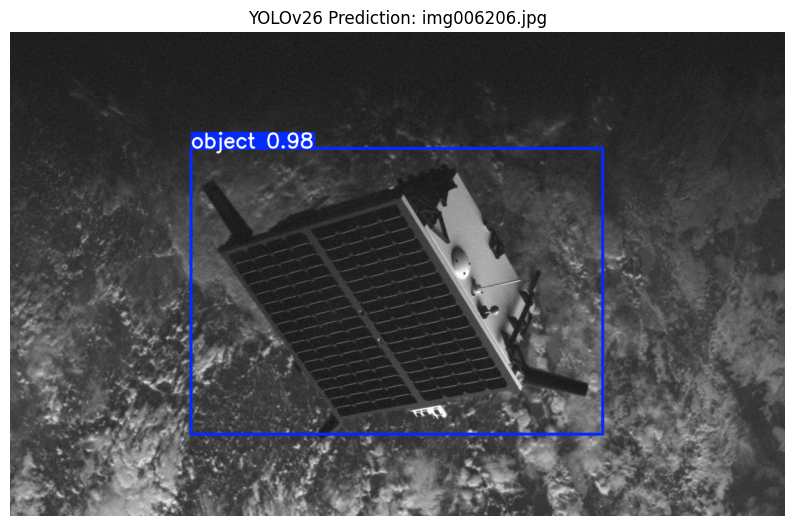


image 1/1 /kaggle/input/datasets/isidorotamassia/speed/speedplusv2/lightbox/images/img005541.jpg: 512x800 1 object, 17.1ms
Speed: 3.1ms preprocess, 17.1ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 800)


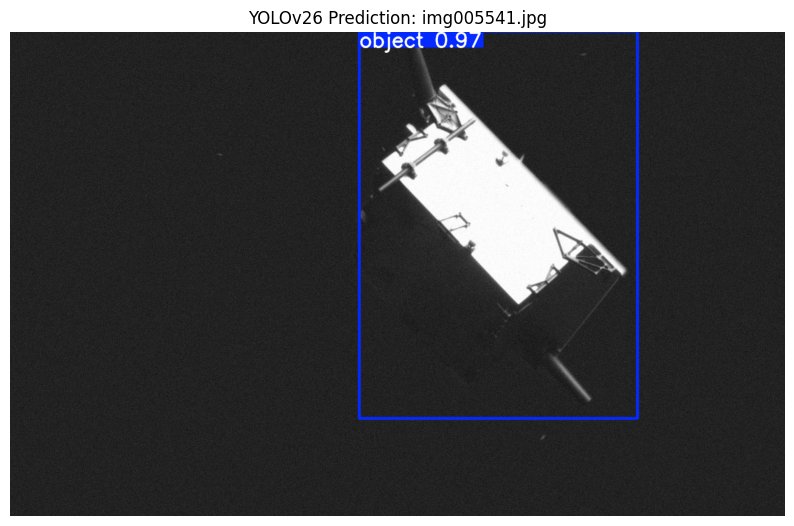


image 1/1 /kaggle/input/datasets/isidorotamassia/speed/speedplusv2/lightbox/images/img005445.jpg: 512x800 1 object, 17.1ms
Speed: 3.1ms preprocess, 17.1ms inference, 0.4ms postprocess per image at shape (1, 3, 512, 800)


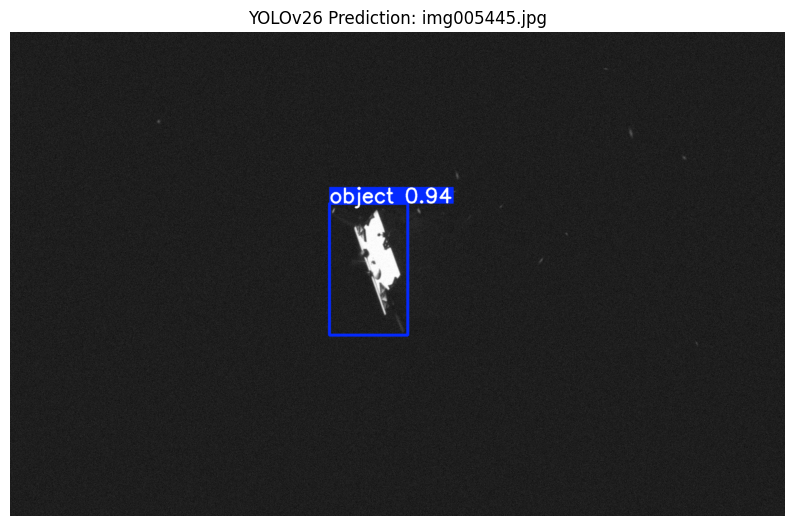


image 1/1 /kaggle/input/datasets/isidorotamassia/speed/speedplusv2/lightbox/images/img001772.jpg: 512x800 1 object, 17.2ms
Speed: 3.5ms preprocess, 17.2ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 800)


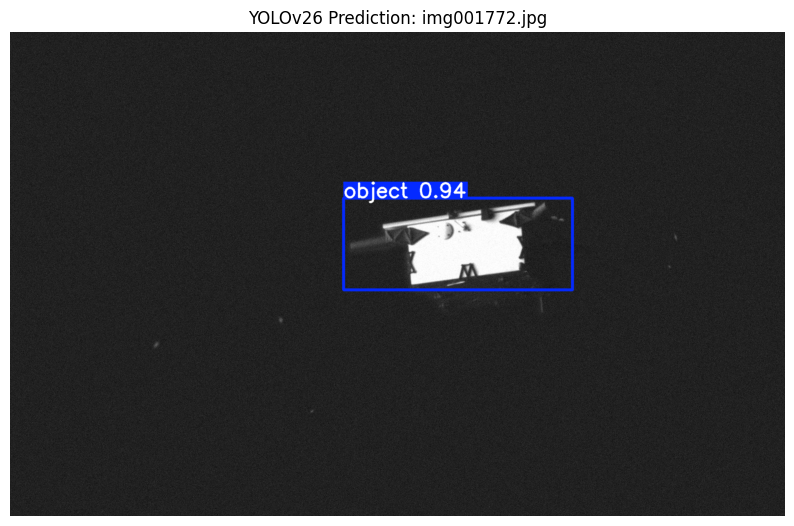


image 1/1 /kaggle/input/datasets/isidorotamassia/speed/speedplusv2/lightbox/images/img003065.jpg: 512x800 1 object, 17.1ms
Speed: 3.2ms preprocess, 17.1ms inference, 0.5ms postprocess per image at shape (1, 3, 512, 800)


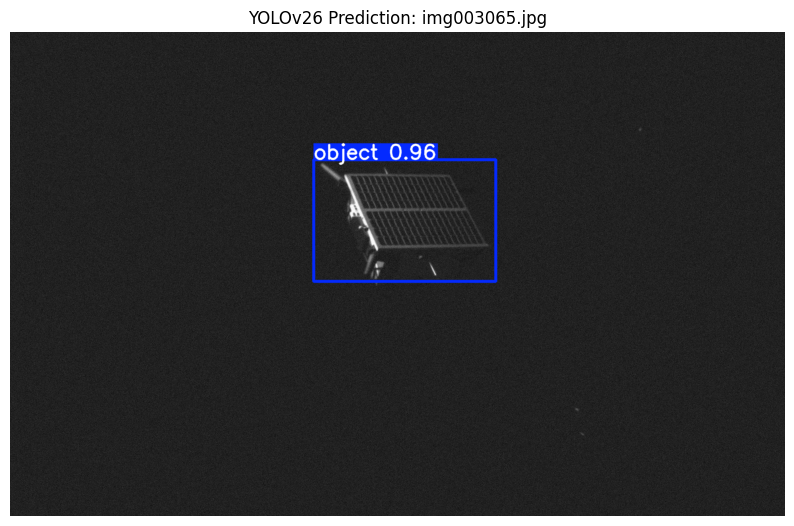

In [13]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
from pathlib import Path

# Load your trained model
model = YOLO('/kaggle/working/runs/yolo26s_satellite/weights/best.pt')

# Directory of images to test (e.g., validation set)
image_dir = Path('/kaggle/input/datasets/isidorotamassia/speed/speedplusv2/lightbox/images')
image_paths = list(image_dir.glob("*.jpg"))[:5]  # visualize first 5 images

# Run inference and plot
for img_path in image_paths:
    results = model(str(img_path))  # run prediction
    im_array = results[0].plot()    # get image with predicted boxes

    # Convert to RGB for matplotlib (OpenCV uses BGR)
    img_rgb = cv2.cvtColor(im_array, cv2.COLOR_BGR2RGB)

    # Display
    plt.figure(figsize=(10, 8))
    plt.imshow(img_rgb)
    plt.title(f"YOLOv26 Prediction: {img_path.name}")
    plt.axis("off")
    plt.show()


In [14]:
# import pandas as pd
# import cv2
# import os
# from ultralytics import YOLO

# df = pd.read_csv("/kaggle/input/projectedkeyptspeed/projected_keypoints_train.csv")
# image_dir = "/kaggle/input/speedsplit/speed/images/trainval"
# yolo = YOLO('//kaggle/input/yolo-best-weights/best.pt') # or yolov8s.pt

# all_boxes = []

# for i, row in df.iterrows():
#     filename = row["filename"]
#     img_path = os.path.join(image_dir, filename)

#     if not os.path.exists(img_path):
#         print(f"Skipping missing: {filename}")
#         all_boxes.append([None] * 4)
#         continue

#     img = cv2.imread(img_path)
#     results = yolo(img, conf=0.1, verbose=False)
#     boxes = results[0].boxes.xyxy.cpu().numpy()

#     if len(boxes) == 0:
#         print(f"No object detected: {filename}")
#         all_boxes.append([None] * 4)
#         continue

#     x1, y1, x2, y2 = boxes[0].astype(int)
#     all_boxes.append([x1, y1, x2, y2])

# # Add boxes to dataframe
# df[["x1", "y1", "x2", "y2"]] = all_boxes

# # Save updated CSV
# df.to_csv("train_cached_boxes.csv", index=False)


In [15]:
# class KeypointDataset(torch.utils.data.Dataset):
#     def __init__(self, bbox_csv, keypoints_csv, image_dir, transform=None):
#         self.image_dir = image_dir
#         self.transform = transform

#         # Load CSVs
#         bbox_df = pd.read_csv(bbox_csv)
#         kpt_df = pd.read_csv(keypoints_csv)

#         # Drop bbox rows with NaNs (failed YOLO detections)
#         bbox_df = bbox_df.dropna(subset=['x1', 'y1', 'x2', 'y2'])

#         # Keep only rows with matching filenames
#         common_files = set(bbox_df['filename']).intersection(set(kpt_df['filename']))
#         self.kpt_df = kpt_df[kpt_df['filename'].isin(common_files)].reset_index(drop=True)
#         self.bbox_df = bbox_df.set_index('filename')  # for fast lookup

#     def __len__(self):
#         return len(self.kpt_df)

#     def __getitem__(self, idx):
#         row = self.kpt_df.iloc[idx]
#         filename = row['filename']
#         img_path = os.path.join(self.image_dir, filename)

#         img = cv2.imread(img_path)
#         img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

#         # Read and safely cast bounding box
#         bbox = self.bbox_df.loc[filename][['x1', 'y1', 'x2', 'y2']]
#         x1, y1, x2, y2 = map(int, bbox)

#         cropped = img[y1:y2, x1:x2]

#         if self.transform:
#             cropped = self.transform(cropped)
#         else:
#             cropped = cv2.resize(cropped, (224, 224))
#             cropped = torch.tensor(cropped / 255., dtype=torch.float32).permute(2, 0, 1)

#         keypoints = []
#         for i in range(11):
#             x = row[f'kpt_{i}_x']
#             y = row[f'kpt_{i}_y']
#             x_norm = (x - x1) / (x2 - x1)
#             y_norm = (y - y1) / (y2 - y1)
#             keypoints.extend([x_norm, y_norm])

#         keypoints = torch.tensor(keypoints, dtype=torch.float32)
#         return cropped, keypoints


In [16]:
# class LightKeypointCNN(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.cnn = nn.Sequential(
#             nn.Conv2d(3, 32, kernel_size=3, padding=1),  # 224x224
#             nn.BatchNorm2d(32),
#             nn.ReLU(),
#             nn.MaxPool2d(2),  # 112x112

#             nn.Conv2d(32, 64, kernel_size=3, padding=1),
#             nn.BatchNorm2d(64),
#             nn.ReLU(),
#             nn.MaxPool2d(2),  # 56x56

#             nn.Conv2d(64, 128, kernel_size=3, padding=1),
#             nn.BatchNorm2d(128),
#             nn.ReLU(),
#             nn.MaxPool2d(2),  # 28x28

#             nn.Conv2d(128, 256, kernel_size=3, padding=1),
#             nn.BatchNorm2d(256),
#             nn.ReLU(),
#             nn.MaxPool2d(2),  # 14x14

#             nn.Conv2d(256, 512, kernel_size=3, padding=1),
#             nn.BatchNorm2d(512),
#             nn.ReLU(),
#             nn.AdaptiveAvgPool2d((1, 1))  # 1x1x512
#         )
#         self.fc = nn.Sequential(
#             nn.Flatten(),
#             nn.Dropout(0.3),
#             nn.Linear(512, 256),
#             nn.ReLU(),
#             nn.Dropout(0.3),
#             nn.Linear(256, 128),
#             nn.ReLU(),
#             nn.Linear(128, 22)  # 11 keypoints × 2
#         )

#     def forward(self, x):
#         x = self.cnn(x)
#         x = self.fc(x)
#         return x


In [17]:
# transform = transforms.Compose([
#     transforms.ToPILImage(),
#     transforms.Resize((224, 224)),
#     transforms.ToTensor()
# ])

# train_dataset = KeypointDataset('/kaggle/working/train_cached_boxes.csv', '/kaggle/input/projectedkeyptspeed/projected_keypoints_train.csv', '/kaggle/input/speedsplit/speed/images/trainval', transform=transform)
# train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)


In [18]:
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# model = LightKeypointCNN().to(device)

# optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-5)  # L2 regularization via weight_decay
# criterion = nn.MSELoss()

# for epoch in range(100):
#     model.train()
#     running_loss = 0.0

#     for imgs, keypoints in train_loader:
#         imgs, keypoints = imgs.to(device), keypoints.to(device)

#         optimizer.zero_grad()
#         preds = model(imgs)
#         loss = criterion(preds, keypoints)
#         loss.backward()
#         optimizer.step()

#         running_loss += loss.item()

#     print(f"Epoch {epoch+1}/100 - Loss: {running_loss / len(train_loader):.4f}")


In [19]:
# torch.save(model.state_dict(), "keypoint_model.pth")


In [20]:
# import matplotlib.pyplot as plt

# def visualize_keypoints(dataset, model, device, num_samples=5):
#     model.eval()
#     for idx in range(num_samples):
#         # Load data
#         img_tensor, gt_keypoints = dataset[idx]
#         row = dataset.kpt_df.iloc[idx]
#         filename = row['filename']
#         bbox = dataset.bbox_df.loc[filename][['x1', 'y1', 'x2', 'y2']]
#         x1, y1, x2, y2 = map(int, bbox)

#         # Load original image
#         orig_path = os.path.join(dataset.image_dir, filename)
#         orig_img = cv2.imread(orig_path)
#         orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

#         # Get prediction
#         input_tensor = img_tensor.unsqueeze(0).to(device)
#         with torch.no_grad():
#             pred_keypoints = model(input_tensor).cpu().squeeze()

#         # Convert normalized [0,1] keypoints → original image coordinates
#         pred_pts = []
#         gt_pts = []
#         for i in range(11):
#             px = pred_keypoints[2*i].item() * (x2 - x1) + x1
#             py = pred_keypoints[2*i+1].item() * (y2 - y1) + y1
#             gx = gt_keypoints[2*i].item() * (x2 - x1) + x1
#             gy = gt_keypoints[2*i+1].item() * (y2 - y1) + y1
#             pred_pts.append((px, py))
#             gt_pts.append((gx, gy))

#         # Plot
#         plt.figure(figsize=(8, 8))
#         plt.imshow(orig_img)
#         plt.title(f"Image: {filename}")

#         # Draw GT keypoints in green
#         for (gx, gy) in gt_pts:
#             plt.scatter(gx, gy, c='green', label='GT', s=30)

#         # Draw predicted keypoints in red
#         for (px, py) in pred_pts:
#             plt.scatter(px, py, c='red', label='Pred', marker='x', s=30)

#         # Draw bbox
#         plt.gca().add_patch(plt.Rectangle((x1, y1), x2-x1, y2-y1,
#                                           edgecolor='blue', facecolor='none', linewidth=1))

#         # Avoid duplicate legend entries
#         handles, labels = plt.gca().get_legend_handles_labels()
#         by_label = dict(zip(labels, handles))
#         plt.legend(by_label.values(), by_label.keys())

#         plt.axis('off')
#         plt.show()
